# 12 - Windowing and Feature Engineering (Solution)

This notebook creates leakage-safe train/validation/test splits at the source-signal level before windowing.

### Step 1 README: Environment Setup
This cell configures robust imports and verifies the runtime environment for feature-engineering workflow.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ROOT = Path.cwd().resolve()
PROJECT_ROOT = None
for candidate in [ROOT, *ROOT.parents]:
    if (candidate / "src" / "edge_ai_course").exists():
        PROJECT_ROOT = candidate
        break
if PROJECT_ROOT is None:
    raise ModuleNotFoundError(
        "Could not find src/edge_ai_course. Run from inside the 'day 5 sensor' folder or a child folder."
    )

SRC = PROJECT_ROOT / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from edge_ai_course.signal_generator import SignalConfig, CLASS_ID_TO_NAME, generate_source_signals
from edge_ai_course.signal_dataset import build_sensor_dataset, save_dataset_artifacts, assert_no_source_leakage
from edge_ai_course.signal_features import extract_features, fft_components
from edge_ai_course.signal_models import train_classical_models, train_cnn_model, convert_to_tflite
from edge_ai_course.signal_visualization import plot_signal_and_fft, plot_feature_distribution, plot_confusion_matrix, plot_comparison_bars
from edge_ai_course.model_analysis import (
    build_comparison_table,
    write_day5_report,
    estimate_classical_pipeline_memory,
    estimate_cnn_pipeline_memory,
)

print("Environment ready for Notebook 12")
print(f"Project root: {PROJECT_ROOT}")
print(f"Pandas version: {pd.__version__}")


Environment ready for Notebook 12
Project root: C:\Users\thenebandaa\OneDrive - West Pharmaceutical Services, Inc\trainings\Edge AI\code\day 5 sensor
Pandas version: 2.2.2


### Step 2 README: Build Leakage-Safe Dataset
This cell generates source signals, performs source-level split, creates windows, enforces leakage checks, and saves artifacts.

{'feature_csv': WindowsPath('C:/Users/thenebandaa/OneDrive - West Pharmaceutical Services, Inc/trainings/Edge AI/code/day 5 sensor/data/sensor/processed/sensor_features.csv'), 'window_npz': WindowsPath('C:/Users/thenebandaa/OneDrive - West Pharmaceutical Services, Inc/trainings/Edge AI/code/day 5 sensor/data/sensor/processed/sensor_windows.npz'), 'source_npz': WindowsPath('C:/Users/thenebandaa/OneDrive - West Pharmaceutical Services, Inc/trainings/Edge AI/code/day 5 sensor/data/sensor/raw/sensor_source_signals.npz'), 'metadata_json': WindowsPath('C:/Users/thenebandaa/OneDrive - West Pharmaceutical Services, Inc/trainings/Edge AI/code/day 5 sensor/data/sensor/metadata/dataset_metadata.json')}
Feature table shape: (6000, 26)
split  class_name                
train  high_frequency_disturbance    1020
       imbalance                     1020
       impulse_fault                 1020
       normal_operation              1020
test   high_frequency_disturbance     240
Name: count, dtype: int

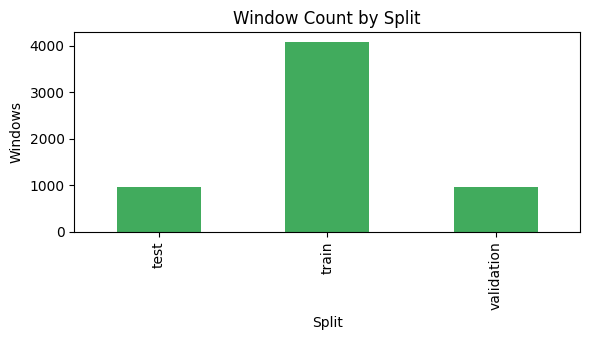

Artifacts are stored under: C:\Users\thenebandaa\OneDrive - West Pharmaceutical Services, Inc\trainings\Edge AI\code\day 5 sensor\data\sensor


,split,source_signal_id,window_id,class_id,class_name,mean,std,variance,rms,maximum,...,crest_factor,signal_energy,dominant_frequency,dominant_magnitude,spectral_centroid,spectral_energy,spectral_entropy,low_band_energy,mid_band_energy,high_band_energy
0,train,c0_s0005,c0_s0005_w000,0,normal_operation,0.016436,0.715066,0.511319,0.715255,1.108616,...,1.578636,130.966845,31.25,126.405197,105.969151,16772.666016,0.066514,16502.253906,208.160934,62.136993
1,train,c0_s0005,c0_s0005_w001,0,normal_operation,0.008936,0.717503,0.514810,0.717558,1.108616,...,1.573568,131.811795,31.25,126.950371,102.951657,16874.527344,0.064025,16611.972656,205.831100,56.722149
2,train,c0_s0005,c0_s0005_w002,0,normal_operation,0.002153,0.709806,0.503824,0.709809,1.105570,...,1.557560,128.980139,31.25,125.680656,108.648442,16510.164062,0.062143,16251.881836,193.897110,63.276150
3,train,c0_s0005,c0_s0005_w003,0,normal_operation,-0.004680,0.704478,0.496289,0.704493,1.085569,...,1.601628,127.055503,31.25,124.673813,105.980807,16263.828125,0.062766,16028.580078,168.969772,66.268028
4,train,c0_s0005,c0_s0005_w004,0,normal_operation,-0.010965,0.708180,0.501519,0.708265,1.085569,...,1.593098,128.419741,31.25,125.439873,106.024061,16442.136719,0.061815,16199.829102,181.507172,59.858788


In [2]:
dataset = build_sensor_dataset(
    config=SignalConfig(sampling_rate=1000, duration_seconds=4.0, random_seed=42),
    mode="quick",
    window_size=256,
    overlap_fraction=0.5,
)
assert_no_source_leakage(dataset)
paths = save_dataset_artifacts(dataset)
print(paths)

features = dataset["feature_table"]
print("Feature table shape:", features.shape)
split_counts = features[["split", "class_name"]].value_counts().head()
print(split_counts)

split_totals = features.groupby("split").size()
plt.figure(figsize=(6, 3.5))
split_totals.plot(kind="bar", color="#41ab5d")
plt.title("Window Count by Split")
plt.xlabel("Split")
plt.ylabel("Windows")
plt.tight_layout()
plt.show()

print("Artifacts are stored under:", PROJECT_ROOT / "data" / "sensor")
features.head()

### Step 3 README: Window Duration and Overlap View
This cell explains window duration math and visualizes overlapping windows from training signals.

In [ ]:
# Window duration explanation
sampling_rate = dataset["config"].sampling_rate
window_size = dataset["window_size"]
window_duration = window_size / sampling_rate
print(f"window_duration = {window_size} / {sampling_rate} = {window_duration:.3f} seconds")

# Visualize overlapping windows from one source signal.
one_signal = dataset["x_train"][0]
second_window = dataset["x_train"][1]
plt.figure(figsize=(10, 3))
plt.plot(one_signal, label="window 1")
plt.plot(second_window, label="window 2", alpha=0.7)
plt.title("Overlapping windows (example)")
plt.xlabel("Sample index")
plt.ylabel("Amplitude")
plt.legend()
plt.tight_layout()
plt.show()

### Step 4 README: Feature Distribution Plots
This cell plots key time/frequency features by class and builds a correlation heatmap for feature diagnostics.

In [ ]:
plot_dir = PROJECT_ROOT / "reports" / "day5" / "plots"
plot_dir.mkdir(parents=True, exist_ok=True)

for feature in ["rms", "kurtosis", "dominant_frequency", "low_band_energy", "mid_band_energy", "high_band_energy"]:
    plot_feature_distribution(features, feature, save_path=plot_dir / f"12_{feature}_by_class.png")

corr = features.select_dtypes(include=["number"]).corr()
plt.figure(figsize=(8, 6))
plt.imshow(corr, cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Feature Correlation Heatmap")
plt.colorbar()
plt.tight_layout()
plt.savefig(plot_dir / "12_feature_correlation.png", dpi=140)
plt.show()

print(f"Saved feature plots to: {plot_dir}")